# Importation

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pyoperators import (
    MPI,
    BlockDiagonalOperator,
    BlockRowOperator,
    DenseOperator,
    DiagonalOperator,
    IdentityOperator,
    PackOperator,
    ReshapeOperator,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from pysimulators.interfaces.healpy.operators import HealpixConvolutionGaussianOperator
from scipy.optimize import minimize

from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.Instrument.Qinstrument import compute_freq
from qubic.lib.Instrument.Qnoise import QubicTotNoise
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing
from qubic.lib.Qscene import QubicScene

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

# Scanning Strategy

## Galactic Coordinates

In [4]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["period"] = 3
qubic_dict["fix_azimuth"]["apply"] = False

### Sweeping pointing
if params["sweeping_pointings"]:
    qubic_dict["random_pointing"] = False
    qubic_dict["sweeping_pointing"] = True

    qubic_dict['angspeed'] = 0.1
    qubic_dict['delta_az'] = 20
    qubic_dict['nsweeps_per_elevation'] = 1
    qubic_dict['duration'] = 3
    # npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
    qubic_dict['period'] = 3600 * qubic_dict["duration"] / params["npointings"]

### Repeat pointing
# qubic_dict["repeat_pointing"] = False

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array(
    [np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)]
)

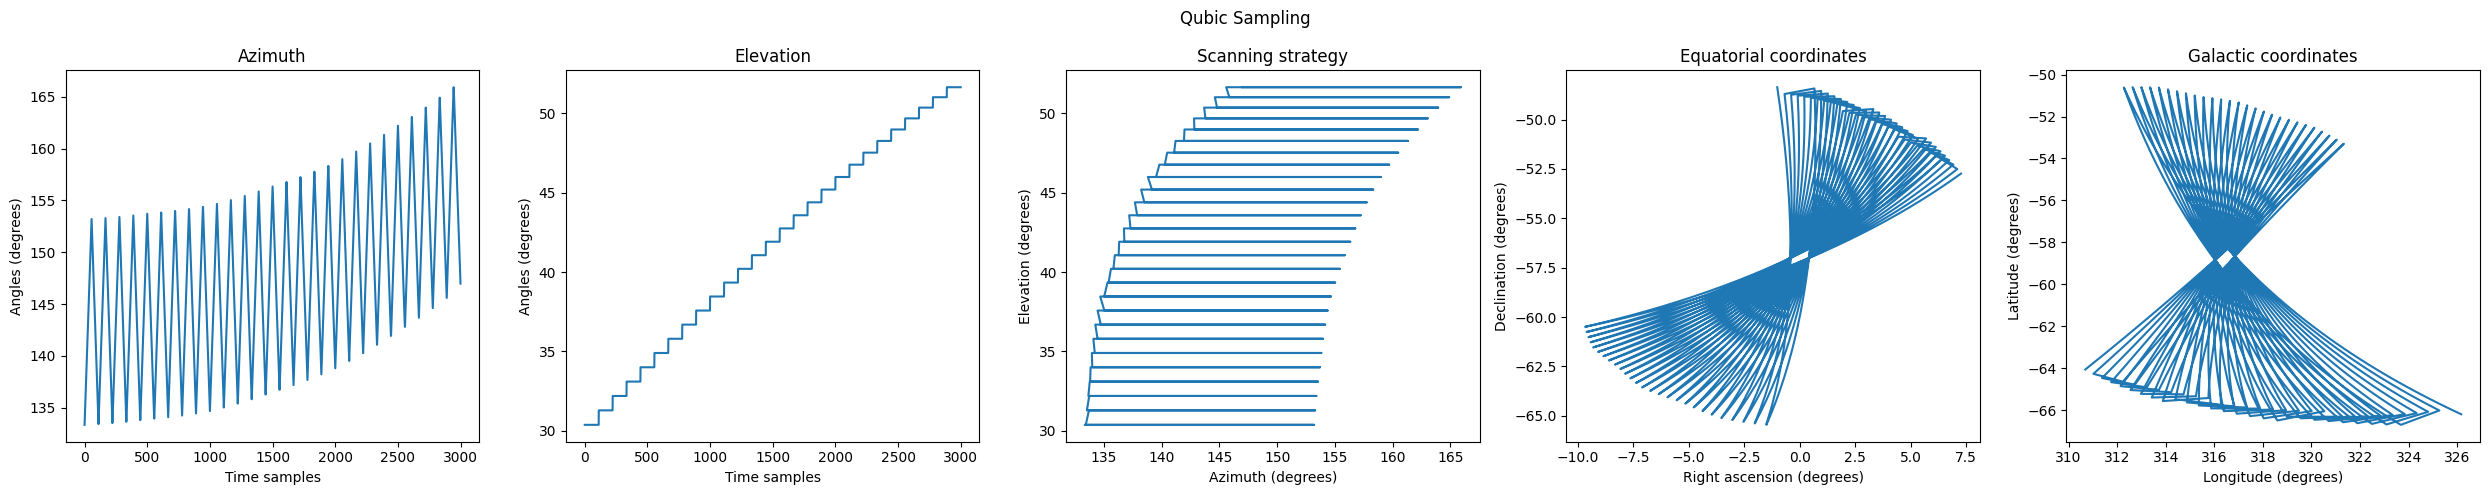

In [5]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot(
    (q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1]
)
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

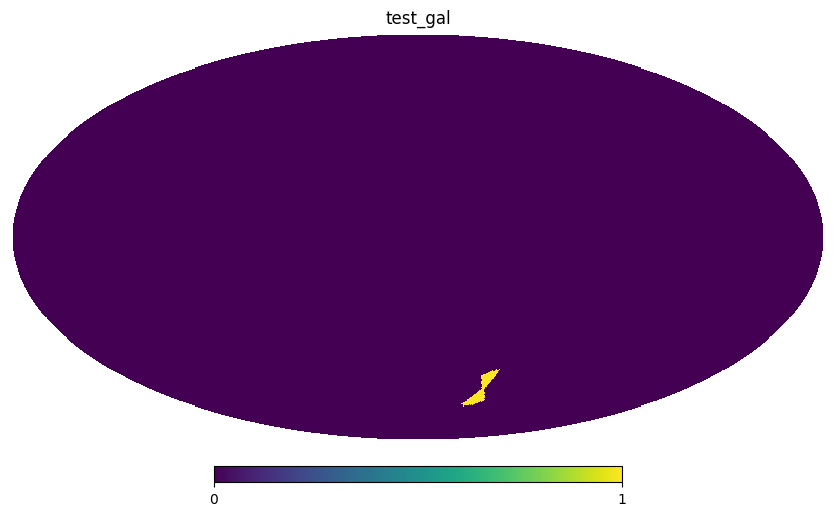

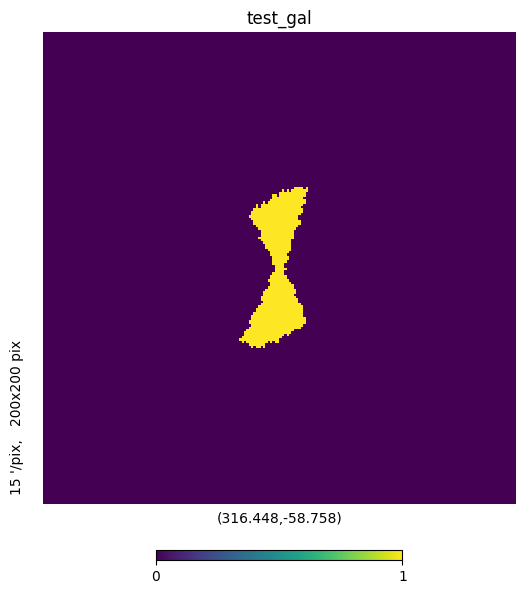

In [6]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Wind

We are adding wind by shifting the scanning strategy. It is roughly equivalent than shifting atm pixels
in the map, but slighlty less expensive in terms of computational ressources. 

## Local Coordinates

In [8]:
### Define scanning strategy for atm observation
q_sampling_local_rec = QubicSampling(
    q_sampling_gal.index.size,
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local_rec.azimuth = q_sampling_gal.azimuth
q_sampling_local_rec.elevation = q_sampling_gal.elevation
q_sampling_local_rec.pitch = q_sampling_gal.pitch
q_sampling_local_rec.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local_rec.fix_az = True
    
if params["wind"]:
    wind_class = WindPerturbation(params, q_sampling_gal)
    q_sampling_local = wind_class.get_deviated_qubic_sampling()
else:
    q_sampling_local = q_sampling_local_rec

147.54781150297273 41.58864088169206


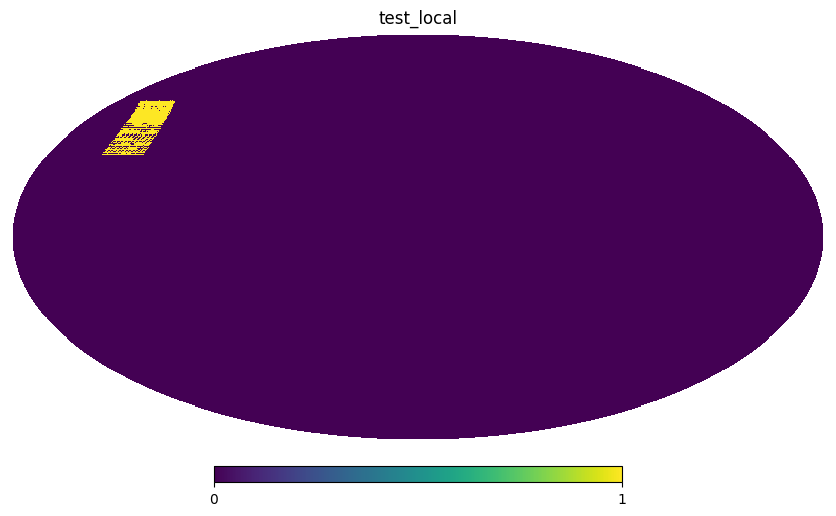

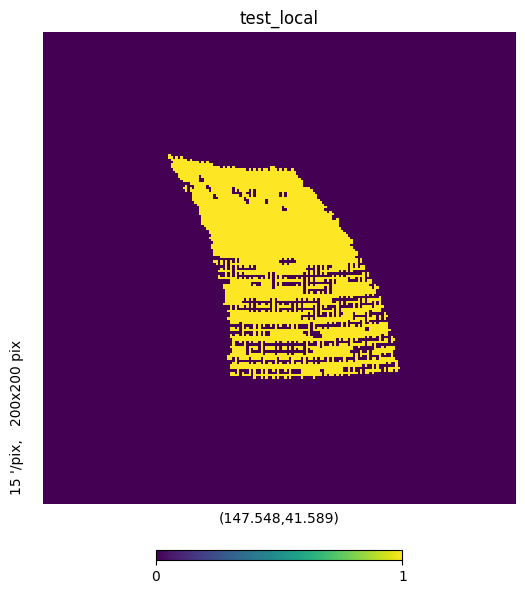

In [9]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

# Input Maps

## CMB

(8, 196608, 3)


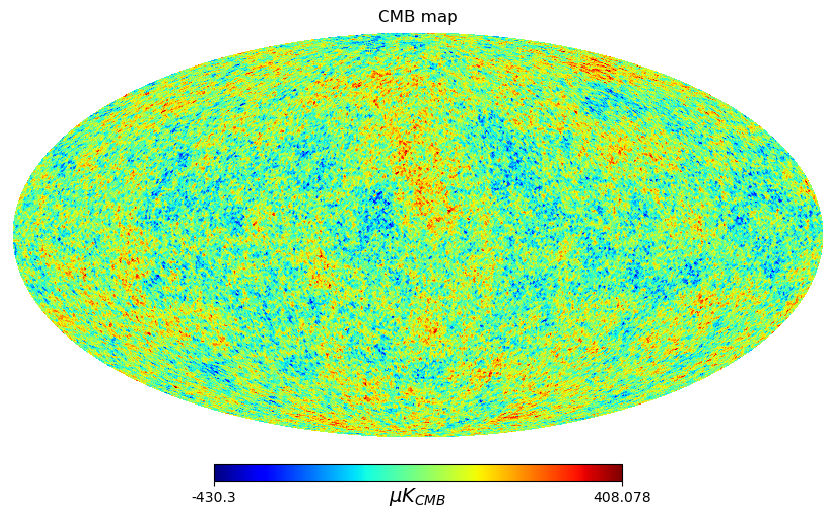

In [ ]:
# Build CMB map
cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
cmb_map = hp.synfast(cl_cmb, params["nside"], new=True, verbose=False).T

cmb_maps = np.ones((params["nsub_in"], hp.nside2npix(params["nside"]), 3))
cmb_maps *= cmb_map[None]
print(cmb_maps.shape)

hp.mollview(cmb_map[:, 0], cmap="jet", title="CMB map", unit=r"$µK_{CMB}$")

## Atmosphere

In [ ]:
atm_maps = np.zeros((cmb_maps.shape))
atm_maps[..., 0] = atm.get_temp_maps(atm.delta_rho_map) / 1e3
print(atm_maps.shape)

(8, 196608, 3)


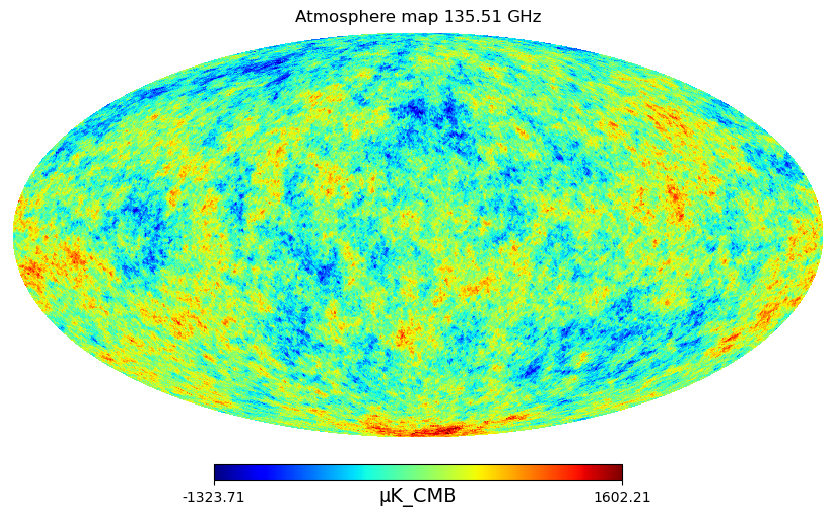

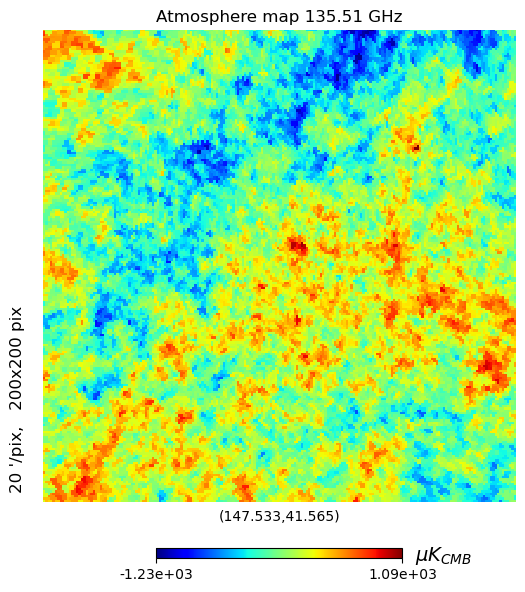

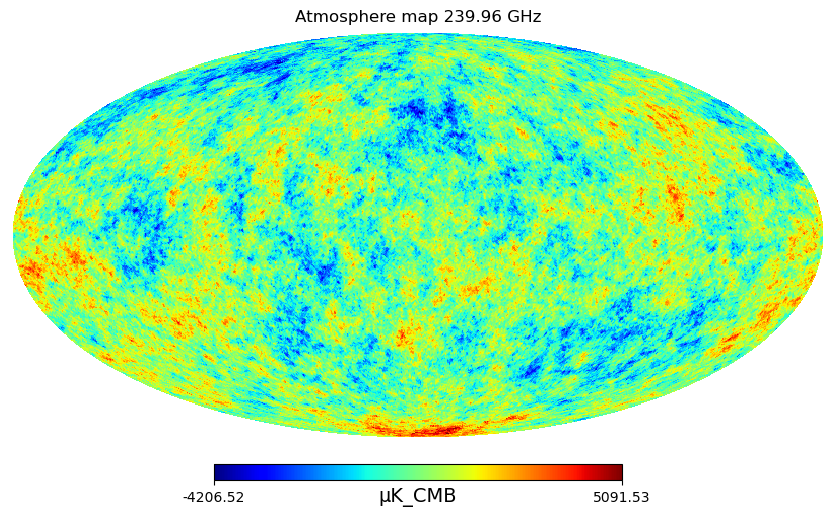

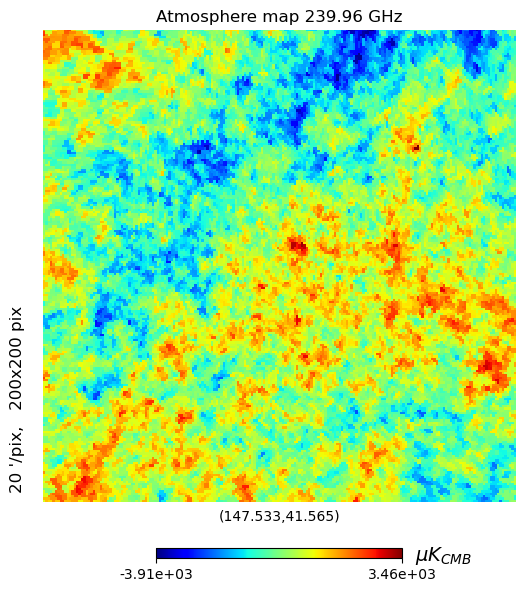

In [ ]:
index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

## Apply convolutions - Input Maps

In [ ]:
if params["convolutions"]:
    fwhm_synthbeam150 = 0.006853589624526168

    _, _, filter_nus150, deltas150, _, _ = compute_freq(
        150,
        int(params["nsub_in"] / 2),
        relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
        frequency_spacing="log",
    )
    _, _, filter_nus220, deltas220, _, _ = compute_freq(
        220,
        int(params["nsub_in"] / 2),
        relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
        frequency_spacing="log",
    )

    nus_tod = np.concatenate((filter_nus150, filter_nus220)) * 1e9
    fwhm_tod = fwhm_synthbeam150 * 150e9 / nus_tod
    print("Frequencies : ", nus_tod)
    print("FWHM : ", fwhm_tod)

    for isub in range(nus_tod.size):
        C = HealpixConvolutionGaussianOperator(fwhm=fwhm_tod[isub])
        atm_maps[isub] = C(atm_maps[isub])
        cmb_maps[isub] = C(cmb_maps[isub])

## Input Maps

In [ ]:
maps = []

if params.get("cmb", False):
    maps.append(cmb_maps)

if params.get("atm", False):
    maps.append(atm_maps)

if maps:
    input_maps = np.concatenate(maps, axis=0)
else:
    input_maps = np.zeros((npix, 3))

print(input_maps.shape)

(8, 196608, 3)


## True maps

In [ ]:
### Build Expected Atm Maps
true_maps = []

# Build the reconstructed maps and frequency by taking the mean inside each reconstructed frequency band
if params["cmb"]:
    true_maps.append(cmb_map)
if params["atm"]:
    true_maps.append(np.mean(atm_maps, axis=0))
true_maps = np.array(true_maps)
if true_maps.shape[0]==1:
    true_maps = true_maps[0]
print(true_maps.shape)

if params["convolutions"]:
    C = HealpixConvolutionGaussianOperator(fwhm=np.mean(fwhm_tod))
    for i in range(true_maps.shape[0]):
        true_maps[i] = C(true_maps[i])

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(196608, 3)


# Mixing Matrix

(8, 2)


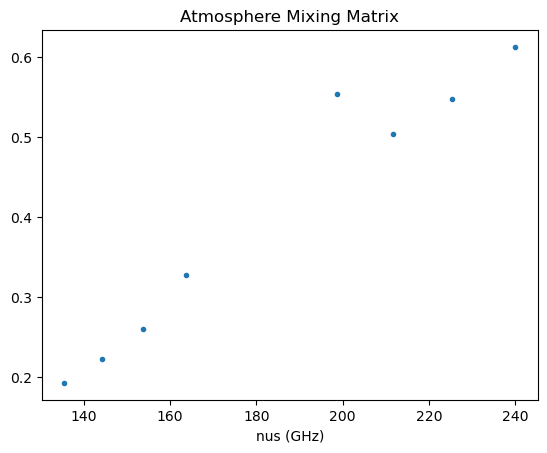

In [ ]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix
mixing_matrix[:, 1] = (
    atm.temperature * atm.integrated_abs_spectrum * atm.mean_water_vapor_density
)
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Build QUBIC Instances

In [ ]:
q_acquisition_local = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local
)

q_acquisition_gal = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_gal
)

qubic_scene = QubicScene(qubic_dict)
qubic_noise = QubicTotNoise(qubic_dict, q_sampling_gal, qubic_scene)

Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (396800,9) elements = 54.4921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (39

In [ ]:
coverage_gal = q_acquisition_gal.coverage
covnorm_gal = coverage_gal / coverage_gal.max()
seenpix_gal = covnorm_gal > params["coverage_cut"]
seenpix_gal_wo_cut = covnorm_gal > 0

coverage_local = q_acquisition_local.coverage
covnorm_local = coverage_local / coverage_local.max()
seenpix_local = covnorm_local > params["coverage_cut"]
seenpix_local_wo_cut = covnorm_local > 0

seenpix = []
if params["cmb"]:
    seenpix.append(seenpix_gal)
if params["atm"] :
    seenpix.append(seenpix_local)
seenpix = np.array(seenpix)
if seenpix.shape[0] == 1:
    seenpix = seenpix[0]

# Build QUBIC Operaotors

In [ ]:
# Galactic Coordinates

H_gal = q_acquisition_gal.get_operator()
print("H_gal :", H_gal.shapein, H_gal.shapeout)

H_gal : (8, 196608, 3) (396800,)
invN_gal : (992, 400) (992, 400)


In [ ]:
# Local Coordinates

H_local = q_acquisition_local.get_operator()

invN_local = q_acquisition_local.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"])

In [ ]:
### Full MM
R = ReshapeOperator((2 * 992, params["npointings"]), (params["npointings"] * 992 * 2))

r = ReshapeOperator((npix, 3), (1, npix, 3))
A_gal = (
    DenseOperator(
        mixing_matrix[:, 0, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)
A_local = (
    DenseOperator(
        mixing_matrix[:, 1, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)

def build_H(H_gal, H_local, A_gal, A_local):

    H_list = []
    if params["cmb"] :
        H_list.append(H_gal(A_gal))
    if params["atm"] :
        H_list.append(H_local(A_local))
        
    shape = len(H_list)
    print(shape)
    print(H_list[0].shapein, H_list[0].shapeout)
    if shape==1:
        return BlockRowOperator(H_list, axisin=0)
    else:
        return BlockRowOperator(H_list, new_axisin=0) # * ReshapeOperator(
    #    (shape, npix, 3), (shape * npix, 3)
    #)
    
H = build_H(H_gal, H_local, A_gal, A_local)

tod = H(true_maps) + qubic_noise.total_noise(1, 1, 1, seed_noise=params["seed"]).ravel()
print(tod.shape)

del H_gal, H_local, H

1
(196608, 3) (396800,)


Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs
(396800,)


# Map-Making

In [ ]:
# rec operators

### Local coordinates
q_acquisition_local = QubicInstrumentType(
    qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling_local_rec
)
H_local = q_acquisition_local.get_operator()
print("H_local :", H_local.shapein, H_local.shapeout)
invN_gal = q_acquisition_gal.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"])
print("invN_local :", invN_local.shapein, invN_local.shapeout)

### Galactic coordinates
q_acquisition_gal = QubicInstrumentType(
    qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling_gal
)
H_gal = q_acquisition_gal.get_operator()
print("H_gal :", H_gal.shapein, H_gal.shapeout)
invN_gal = q_acquisition_gal.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"])
print("invN_gal :", invN_gal.shapein, invN_gal.shapeout)

### Joint operators
H = build_H(H_gal, H_local, A_gal, A_local)
R = ReshapeOperator(invN_gal.shapein, H.shapeout)
invN = R(invN_gal(R.T))

In [ ]:
# preconditioner

ncomp = 2
nside = params["nside"]
npix = 12 * nside**2
nsub = params["nsub_rec"]
no_det = 992

stacked_dptdp_inv = np.empty((ncomp, npix))

q_acq = [q_acquisition_gal, q_acquisition_local]

def get_preconditioner(H_arr):   # H_arr = [H_gal, H_local]
    for icomp in range(ncomp):
        H_qubic = H_arr[icomp].operator

        stacked_dptdp_inv_nsub = np.empty((nsub, npix))

        for j_nsub in range(nsub):
            H_single = H_qubic[j_nsub]

            D = H_single.operands[1]
            P = H_single.operands[4]
            sh = P.matrix.data.index.shape

            point_per_det = sh[0] // no_det
            mapPtP_perdet_seq = np.empty((no_det, npix))

            for det in range(no_det):
                start, end = det * point_per_det, (det + 1) * point_per_det
                indices = P.matrix.data.index[start:end, :]
                weights = P.matrix.data.r11[start:end, :]
                flat_indices = indices.ravel()
                flat_weights = weights.ravel()

                mapPitPi = np.bincount(
                    flat_indices, weights=flat_weights**2, minlength=npix
                )
                mapPtP_perdet_seq[det, :] = mapPitPi

            D_sq = D.data**2
            mapPtP_seq_scaled = D_sq[:, np.newaxis] * mapPtP_perdet_seq
            dptdp = mapPtP_seq_scaled.sum(axis=0)

            # Safe inversion
            dptdp_inv = np.zeros_like(dptdp)
            nonzero = dptdp != 0
            dptdp_inv[nonzero] = 1.0 / dptdp[nonzero]
            stacked_dptdp_inv_nsub[j_nsub] = dptdp_inv

        stacked_dptdp_inv[icomp] = stacked_dptdp_inv_nsub.sum(axis=0)

    preconditioner = BlockDiagonalOperator(
        [DiagonalOperator(ci, broadcast="rightward") for ci in stacked_dptdp_inv],
        new_axisin=0,
    )
    
    return preconditioner

In [ ]:
# Starting point

# Start from maps full of 0
maps_rec = true_maps.copy()
maps_rec *= 0

# Start from uniform mixing-matrix (= 1)
mixing_matrix_rec = np.ones_like(mixing_matrix)

# Map-Making library

In [ ]:
def get_H(Amm):
    A_local = (
        DenseOperator(
            Amm[:, 1, None],
            broadcast="rightward",
            shapein=(1, npix, 3),
            shapeout=(params["nsub_in"], npix, 3),
        )
        * r
    )
    H = build_H(H_gal, H_local, A_gal, A_local)
    return H
    

def get_tod_comp(H):
    tod_comp = np.zeros((2, nsub, 992*params["npointings"]))
    for icomp in range(2):
        for jnus in range(nsub):
            tod_comp[icomp, jnus] = H.operands[0].operands[icomp].operands[1].operands[jnus](maps_rec[icomp]).ravel()
    return tod_comp
    

def call_pcg(A, b, x0, max_iter=5, M=None):
    algo = PCGAlgorithm(
        A,
        b,
        comm,
        x0=x0,
        tol=1e-12,
        maxiter=max_iter,
        disp=True,
        M=M,
        center=[0, -57],
        reso=15,
        seenpix=seenpix,
        input=true_maps,
    )
    try:
        result = algo.run()
        success = True
        message = "Success"
    except AbnormalStopIteration as e:
        result = algo.finalize()
        success = False
        message = str(e)

    return result

In [ ]:
def get_chi2(x, tod_comp):
    mm = np.empty(mixing_matrix_rec.shape)
    mm[:, 0] = mixing_matrix_rec[:, 0]
    mm[:, 1] = x
    tod_sim = np.einsum('ij,jik->k', mm, tod_comp)
    
    res = tod - tod_sim
    chi2 = 0.5 * (np.dot(res.T, invN(res)))
    return chi2


def fit_mm(mixing_matrix, tod_comp):
    chi2 = get_chi2

    Ai = minimize(
        chi2,
        x0=mixing_matrix[:, 1],
        method="L-BFGS-B",
        # tol=1e-10,
        args=tod_comp
    ).x
    return Ai

# Run Map-Making

In [ ]:
# Fix CMB Intensity + Atm Polarisation
mask = np.ones(true_maps.shape)              # Mask for 2 components : CMB & Atm
if params["cmb"] and not params["atm"]:
    mask[:, 0] = 0                               # CMB Intensity
elif params["cmb"] and params["atm"]:
        mask[0, :, 0] = 0
        mask[1, :, [1,2]] = 0                           # Atm Polarisation
elif not params["cmb"] and params["atm"]:
    mask[: , [1,2]] = 0
if params["fix_maps"]:
    P = PackOperator(mask).T                        # Build Mask Operator
else:
    P = IdentityOperator()
x_masked = true_maps * (1-mask)
x = P.T(maps_rec * 0)

In [ ]:
# Run PCG
convergence = []

# Reconstruction loop
for iloop in range(params["n_loop"]):
    print("=====================================")
    print("Iteration : ", iloop) 
    
    ### fit pixels
    print("-------------------------------------")
    print("Fit Maps :")
    print("-------------------------------------")
    H = get_H(mixing_matrix_rec)
    A = P.T * H.T * invN * H * P
    b = P.T * H.T * invN * (H(true_maps) - H(x_masked))
    
    if params["preconditioner"]:
        M = get_preconditioner([H.operands[0].operands[0], H.operands[0].operands[1]])  
    else:
        M=None
    
    if params["iterative_iter"]:
        n_iter=iloop
    else:
        n_iter=params["n_iter"]

    result = call_pcg(A, b, x,  max_iter=n_iter, M=M)
    output = result["x"].copy()
    print("Previous Maps: ", maps_rec[seenpix].mean(axis=0))
    
    if params["fix_maps"]:
        if params["cmb"] and params["atm"]:
            maps_rec[0, :, 1:] = output[: npix * 2].reshape(npix, 2)     # Update CMB Pol
            maps_rec[1, :, 0] = output[npix*2:]                          # Update Atm Intensity
        elif params["cmb"] and not params["atm"]:
            maps_rec[:, 1:] = output[:npix*2].reshape(npix,2)
        elif not params["cmb"] and params["atm"]:
            print(maps_rec.shape, output.shape)
            print(maps_rec[:, 0].shape, output[npix*2:].shape)
            maps_rec[:, 0] = output
    else:
        maps_rec=output
        
    convergence.append(result["convergence"])
    print("Next Maps: ", maps_rec[seenpix].mean(axis=0))
    print("Residual Maps: ", (true_maps-maps_rec)[seenpix].mean(axis=0))
    x = P.T(maps_rec)

    ### fit mixing matrix
    if params["fit_mixing_matrix"]:
        print("-------------------------------------")
        print("Fit Mixing Matrix :")
        print("-------------------------------------")
        print("Previous MM: ", mixing_matrix_rec[:, 1])
        tod_comp = get_tod_comp(H)
        mixing_matrix_rec[:, 1] = fit_mm(mixing_matrix_rec, tod_comp)
        print("Next MM : ", mixing_matrix_rec[:, 1])
        print("Residual : ", (mixing_matrix - mixing_matrix_rec)[:, 1])
    else:
        mixing_matrix_rec = mixing_matrix
        
    print("-------------------------------------")
    print("Fit Wind :")
    print("-------------------------------------")
    print("=====================================")

Iteration :  0
-------------------------------------
Fit Maps :
-------------------------------------
1
(196608, 3) (396800,)
 Iter     Tol      time
   1: 3.2461e-01 1.29904 [0. 0. 0. ... 0. 0. 0.]
   2: 1.1384e-01 0.79797 [0. 0. 0. ... 0. 0. 0.]
   3: 6.4833e-02 0.90047 [0. 0. 0. ... 0. 0. 0.]
   4: 3.8705e-02 0.90375 [0. 0. 0. ... 0. 0. 0.]
   5: 2.9731e-02 0.79737 [0. 0. 0. ... 0. 0. 0.]
   6: 2.6500e-02 1.20050 [0. 0. 0. ... 0. 0. 0.]
   7: 1.7448e-02 2.69840 [0. 0. 0. ... 0. 0. 0.]
   8: 1.3042e-02 0.90078 [0. 0. 0. ... 0. 0. 0.]
   9: 1.1128e-02 0.89810 [0. 0. 0. ... 0. 0. 0.]
  10: 1.1763e-02 0.80223 [0. 0. 0. ... 0. 0. 0.]
Previous Maps:  [0. 0. 0.]
(196608, 3) (196608,)
(196608,) (0,)
Next Maps:  [78.37302239  0.          0.        ]
Residual Maps:  [-5.70741629  0.          0.        ]


# PCG Plots

In [ ]:
print(convergence[-1][-1])

0.011763214506978177


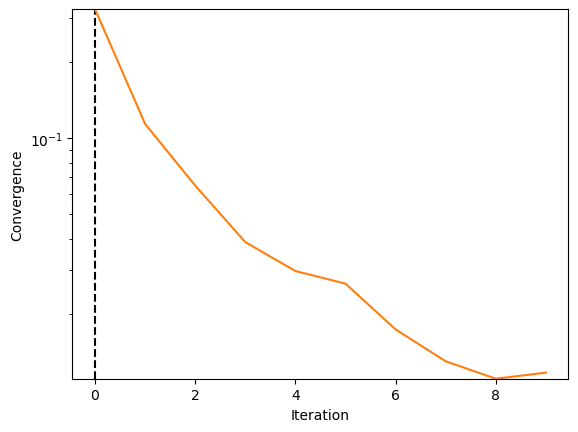

In [ ]:
if params["iterative_iter"]:
    offset = 0

    for iloop in range(params["n_loop"]):
        arr = np.arange(offset, offset + iloop)
        offset += iloop
        plt.plot(arr, convergence[iloop])
        # plt.vlines(arr[iloop][-1], np.min(convergence[iloop]), np.max(convergence[iloop]), "k", "--")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel="Convergence")
else:
    conv = np.concatenate(np.array(convergence))
    for i_loop in range(params["n_loop"]):
        plt.plot(i_loop)
        plt.vlines(params["n_iter"] * i_loop, np.min(conv), np.max(conv), "k", "--")
    plt.plot(conv)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel="Convergence")
    plt.ylim([np.min(convergence), convergence[0][0]])

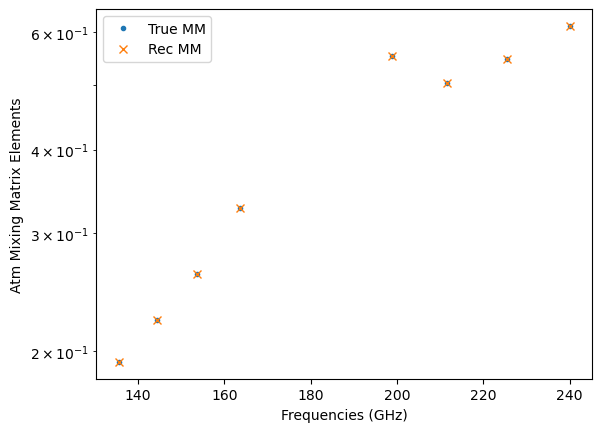

In [ ]:
plt.plot(atm.frequencies, mixing_matrix[:, 1], ".",label="True MM")
plt.plot(atm.frequencies, mixing_matrix_rec[:, 1], "x", label="Rec MM")
plt.legend()
plt.xlabel("Frequencies (GHz)")
plt.ylabel("Atm Mixing Matrix Elements")
plt.yscale("log")

In [ ]:
input = true_maps.copy()
output = maps_rec
residual = output - input

# Maps Plots

In [ ]:
if params["cmb"] and params["atm"]:
    input_cmb = input[0, :, 1:]
    input_atm = input[1, : , :1]

    output_cmb = output[0, :, 1:]
    output_atm = output[1, : , :1]

    residual_cmb = residual[0, :, 1:]
    residual_atm = residual[1, : , :1]
elif params["cmb"] and not params["atm"]:
    input_cmb = input[:, 1:]
    output_cmb = output[:, 1:]
    residual_cmb = residual[:, 1:]
elif not params["cmb"] and params["atm"]:
    input_atm = input[:, :1]
    output_atm = output[:, :1]
    residual_atm = residual[:, :1]

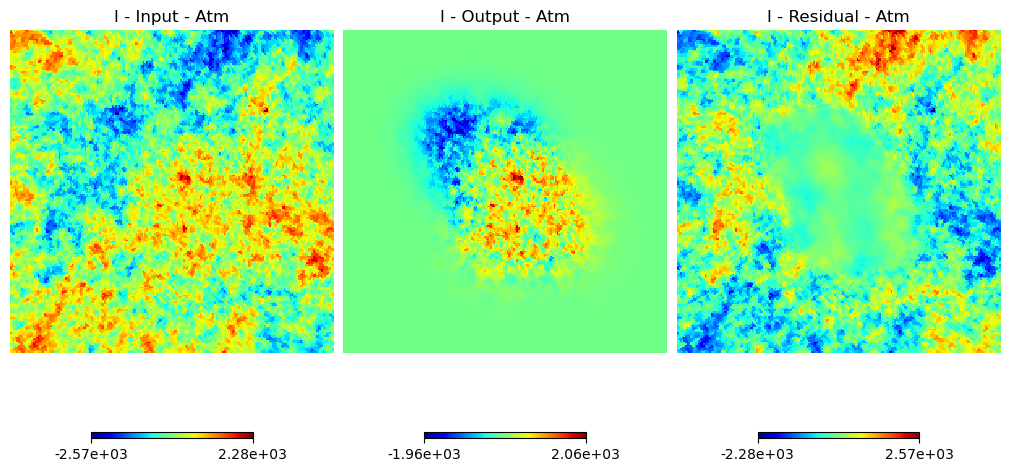

In [ ]:
reso = 20

if params["fix_maps"]:

    configs = []
    if params["cmb"]:
        configs.append(("CMB", input_cmb, output_cmb, residual_cmb,
            center_gal, seenpix_gal, ["Q", "U"], (10, 9))
            
        )

    if params["atm"]:
        configs.append(
            ("Atm", input_atm, output_atm, residual_atm,
            center_local, seenpix_local, ["I"], (10, 10))
        )

    for name, data_in, data_out, data_res, center, seenpix, stk, figsize in configs:

        plt.figure(figsize=figsize)

        for istk, s in enumerate(stk):
            for i, (data, label) in enumerate(
                [(data_in, "Input"), (data_out, "Output"), (data_res, "Residual")]
            ):
                hp.gnomview(
                    data[:, istk],
                    reso=reso,
                    rot=center,
                    cmap="jet",
                    sub=(len(stk), 3, istk * 3 + i + 1),
                    title=f"{s} - {label} - {name}",
                    notext=True,
                )

        plt.tight_layout()

else:

    stk = ["I", "Q", "U"]

    configs = []
    if params["cmb"]:
        configs.append(("CMB", 0, center_gal, seenpix_gal))
    if params["atm"]:
        configs.append(("Atm", 1, center_local, seenpix_local))

    nrows = len(configs) * len(stk)

    for imap, (name, idx_map, center, seenpix) in enumerate(configs):
        plt.figure(figsize=(8, 18))
        for istk, s in enumerate(stk):

            row = imap * len(stk) + istk

            for icol, (data, label) in enumerate(
                [(input, "Input"), (output, "Output"), (residual, "Residual")]
            ):
                hp.gnomview(
                    data[idx_map, :, istk],
                    reso=reso,
                    rot=center,
                    min=min_input[idx_map, istk],
                    max=max_input[idx_map, istk],
                    cmap="jet",
                    sub=(nrows, 3, row * 3 + icol + 1),
                    title=f"{s} - {label} - {name}",
                    notext=True,
                )

    plt.tight_layout()

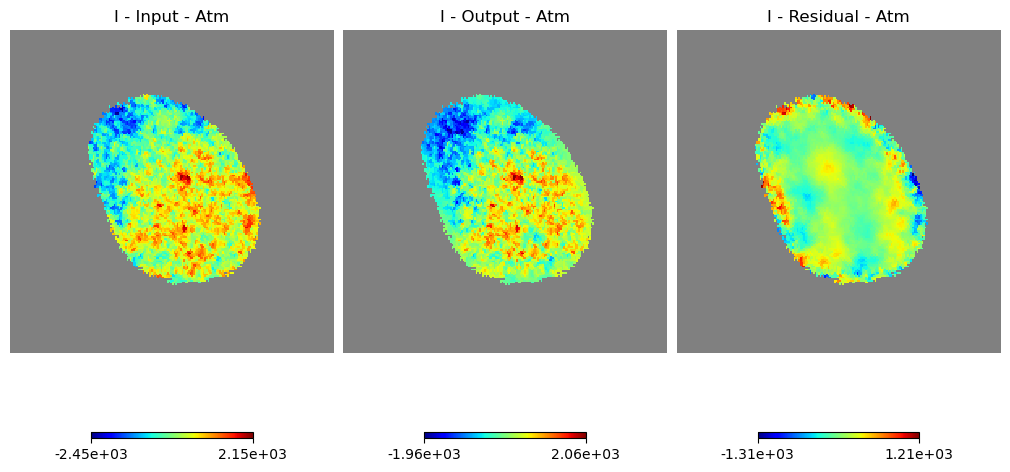

In [ ]:
reso = 20

if params["fix_maps"]:

    for name, data_in, data_out, data_res, center, seenpix, stk, figsize in configs:
        plt.figure(figsize=figsize)
        data_in[~seenpix] = hp.UNSEEN
        data_out[~seenpix] = hp.UNSEEN
        data_res[~seenpix] = hp.UNSEEN
        for istk, s in enumerate(stk):
            for i, (data, label) in enumerate(
                [(data_in, "Input"), (data_out, "Output"), (data_res, "Residual")]
            ):
                hp.gnomview(
                    data[:, istk],
                    reso=reso,
                    rot=center,
                    cmap="jet",
                    sub=(len(stk), 3, istk * 3 + i + 1),
                    title=f"{s} - {label} - {name}",
                    notext=True,
                )

        plt.tight_layout()

else:

    stk = ["I", "Q", "U"]

    nrows = len(configs) * len(stk)

    for imap, (name, idx_map, center, seenpix) in enumerate(configs):
        plt.figure(figsize=(8, 18))
        input[idx_map, ~seenpix, :] = hp.UNSEEN
        output[idx_map, ~seenpix, :] = hp.UNSEEN
        residual[idx_map, ~seenpix, :] = hp.UNSEEN

        for istk, s in enumerate(stk):

            row = imap * len(stk) + istk

            for icol, (data, label) in enumerate(
                [(input, "Input"), (output, "Output"), (residual, "Residual")]
            ):
                hp.gnomview(
                    data[idx_map, :, istk],
                    reso=reso,
                    rot=center,
                    min=min_input[idx_map, istk],
                    max=max_input[idx_map, istk],
                    cmap="jet",
                    sub=(nrows, 3, row * 3 + icol + 1),
                    title=f"{s} - {label} - {name}",
                    notext=True,
                )

    plt.tight_layout()